In [25]:
# Core libraries
import os
import random
import itertools
import functools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import copy
from math import pi
from concurrent.futures import ProcessPoolExecutor
from scipy.spatial.distance import pdist, squareform
from sklearn.preprocessing import MinMaxScaler, StandardScaler, minmax_scale
from ema_workbench import ScalarOutcome
# EMA Workbench core modules
from ema_workbench import (
    Model, Policy, Scenario,
    ema_logging, save_results, load_results,
    MultiprocessingEvaluator
)
from ema_workbench.analysis import (
    prim, cart, parcoords, dimensional_stacking
)
from ema_workbench.em_framework.optimization import (
    ArchiveLogger, EpsilonProgress, to_problem,
    epsilon_nondominated, rebuild_platypus_population
)
from platypus import Hypervolume

# Local modules
from problem_formulation import get_model_for_problem_formulation
from dike_model_function import DikeNetwork
from assignment_10_scenario_selection import find_maxdiverse_scenarios


NameError: name 'initialize_model' is not defined

In [2]:
def initialize_model(problem_formulation_id=3):
    """
    Initialize the dike model with a selected problem formulation.
    """
    ema_logging.log_to_stderr(ema_logging.INFO)
    model, planning_steps = get_model_for_problem_formulation(problem_formulation_id)
    return model, planning_steps


# Call the function
dike_model, planning_steps = initialize_model()


In [ ]:
def evaluate_do_nothing_policy(model, n_scenarios=10000, save_path="scenario_selection.tar.gz"):
    """
    Runs the model for a 'do nothing' baseline policy across scenarios,
    and saves the results to a compressed file.
    """
    do_nothing = Policy("do nothing", **{lever.name: 0 for lever in model.levers})

    with MultiprocessingEvaluator(model) as evaluator:
        results = evaluator.perform_experiments(
            scenarios=n_scenarios,
            policies=[do_nothing]
        )
        save_results(results, save_path)


# Run the evaluation
evaluate_do_nothing_policy(dike_model)


In [3]:
def load_scenario_results(file_path="scenario_selection.tar.gz"):
    """
    Load model results from a previously saved file.
    """
    return load_results(file_path)


# Load the results
experiments, outcomes = load_scenario_results()


In [10]:
def filter_and_select_scenarios(experiments, outcomes, method=3):
    """
    Filter and select key scenarios based on:
    method=1: median filter
    method=2: percentile filter
    method=3: diversity-based selection

    Returns:
        selected_experiments, selected_outcomes, filtered_mask, selected_indices
    """
    outcome_names = [
        'RfR Total Costs',
        'Expected Evacuation Costs',
        'A.5 Total Costs',
        'A.5_Expected Number of Deaths'
    ]
    preferences = {name: +1 for name in outcome_names}

    # Step 1: Filtering
    if method == 1:
        thresholds = {o: np.median(outcomes[o]) for o in outcome_names}
        mask = np.ones(len(experiments), dtype=bool)
        for o in outcome_names:
            mask &= outcomes[o] >= thresholds[o]
    elif method == 2:
        percentile = 90
        thresholds = {
            o: np.percentile(outcomes[o], percentile) for o in outcome_names
        }
        mask = np.ones(len(experiments), dtype=bool)
        for o in outcome_names:
            mask &= outcomes[o] >= thresholds[o]
    elif method == 3:
        mask = np.ones(len(experiments), dtype=bool)
    else:
        raise ValueError("Method must be 1, 2 or 3")

    # Step 2: Normalize outcomes
    outcomes_df = pd.DataFrame({
        k: v[mask] for k, v in outcomes.items() if k in outcome_names
    })
    scaler = MinMaxScaler()
    norm_outcomes = pd.DataFrame(
        scaler.fit_transform(outcomes_df),
        index=outcomes_df.index,
        columns=outcomes_df.columns
    )

    # Step 3: Selection strategy
    if method == 3:
        distances = squareform(pdist(norm_outcomes.values))
        samples = [random.sample(range(len(norm_outcomes)), 5) for _ in range(100000)]

        partial_func = functools.partial(find_maxdiverse_scenarios, distances)
        with ProcessPoolExecutor(max_workers=os.cpu_count()) as executor:
            chunks = np.array_split(samples, os.cpu_count())
            results = list(itertools.chain.from_iterable(executor.map(partial_func, chunks)))

        results.sort(key=lambda r: r[0], reverse=True)
        _, best_indices = results[0]
    else:
        sums = norm_outcomes.sum(axis=1)
        best_idx = sums.idxmin()
        worst_idx = sums.idxmax()
        best_indices = [
            norm_outcomes.index.get_loc(best_idx),
            norm_outcomes.index.get_loc(worst_idx)
        ]

    selected_ids = outcomes_df.iloc[list(best_indices)].index
    selected_experiments = experiments.loc[selected_ids]
    selected_outcomes = pd.DataFrame({
        k: outcomes[k][selected_ids] for k in outcome_names
    })

    return selected_experiments, selected_outcomes, mask, selected_ids


# Run the scenario selection
selected_experiments, selected_outcomes, mask, selected_ids = filter_and_select_scenarios(
    experiments, outcomes, method=3
)


In [ ]:
def save_selected_experiments(df, filename="selected_experiments.csv"):
    """
    Save selected experiments to disk.
    """
    df.to_csv(filename, index=True)

In [4]:
def load_selected_experiments(filename="selected_experiments.csv"):
    """
    Load selected experiments from disk.
    """
    return pd.read_csv(filename, index_col=0)

selected_experiments = load_selected_experiments()

In [5]:
selected_experiments

,A.0_ID flood wave shape,A.1_Bmax,A.1_Brate,A.1_pfail,A.2_Bmax,A.2_Brate,A.2_pfail,A.3_Bmax,A.3_Brate,A.3_pfail,...,A.3_DikeIncrease 2,A.4_DikeIncrease 0,A.4_DikeIncrease 1,A.4_DikeIncrease 2,A.5_DikeIncrease 0,A.5_DikeIncrease 1,A.5_DikeIncrease 2,scenario,policy,model
7284,58,180.947664,10.0,0.833816,333.489628,1.0,0.509235,30.526142,1.5,0.700647,...,0,0,0,0,0,0,0,7284,do nothing,dikesnet
6572,89,182.082884,10.0,0.003718,251.367552,1.0,0.486604,49.841388,1.0,0.633640,...,0,0,0,0,0,0,0,6572,do nothing,dikesnet
7638,36,167.798248,10.0,0.656545,275.795062,10.0,0.541815,243.445608,10.0,0.822534,...,0,0,0,0,0,0,0,7638,do nothing,dikesnet
8006,77,72.908195,1.0,0.294116,168.050401,1.5,0.451919,265.622466,1.0,0.668413,...,0,0,0,0,0,0,0,8006,do nothing,dikesnet
2927,70,271.452405,1.5,0.661892,116.974563,10.0,0.640391,286.008882,1.5,0.898327,...,0,0,0,0,0,0,0,2927,do nothing,dikesnet


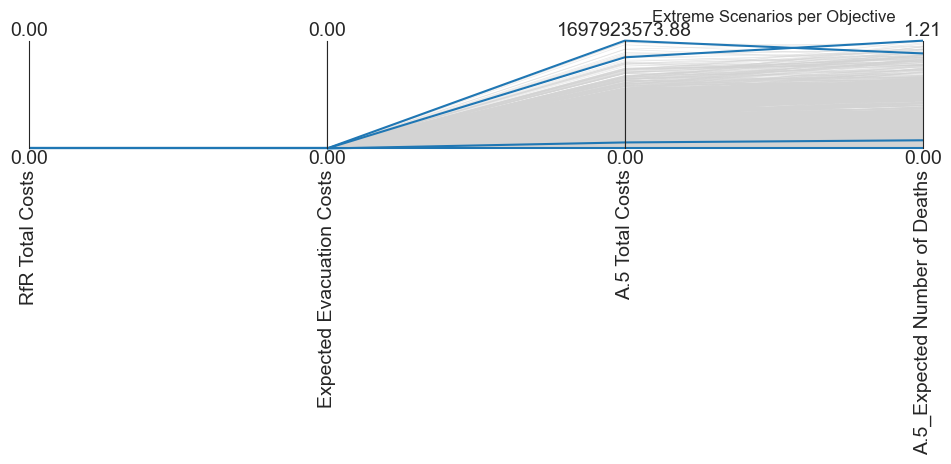

In [12]:
def plot_extreme_outcomes(outcomes, outcome_names):
    """
    Plot a parallel coordinates chart highlighting the scenarios
    with extreme values (min and max) for each outcome.
    """
    all_data = pd.DataFrame({k: outcomes[k] for k in outcome_names})
    extreme_indices = pd.concat([all_data.idxmin(), all_data.idxmax()]).unique()

    limits = parcoords.get_limits(all_data)
    axes = parcoords.ParallelAxes(limits)
    axes.plot(all_data, color='lightgrey', lw=0.5, alpha=0.5)
    axes.plot(all_data.loc[extreme_indices], color=sns.color_palette()[0], lw=1.5)

    plt.gcf().set_size_inches((10, 4))
    plt.title("Extreme Scenarios per Objective")
    plt.show()


# Call the function
plot_extreme_outcomes(outcomes, [
    'RfR Total Costs',
    'Expected Evacuation Costs',
    'A.5 Total Costs',
    'A.5_Expected Number of Deaths'
])


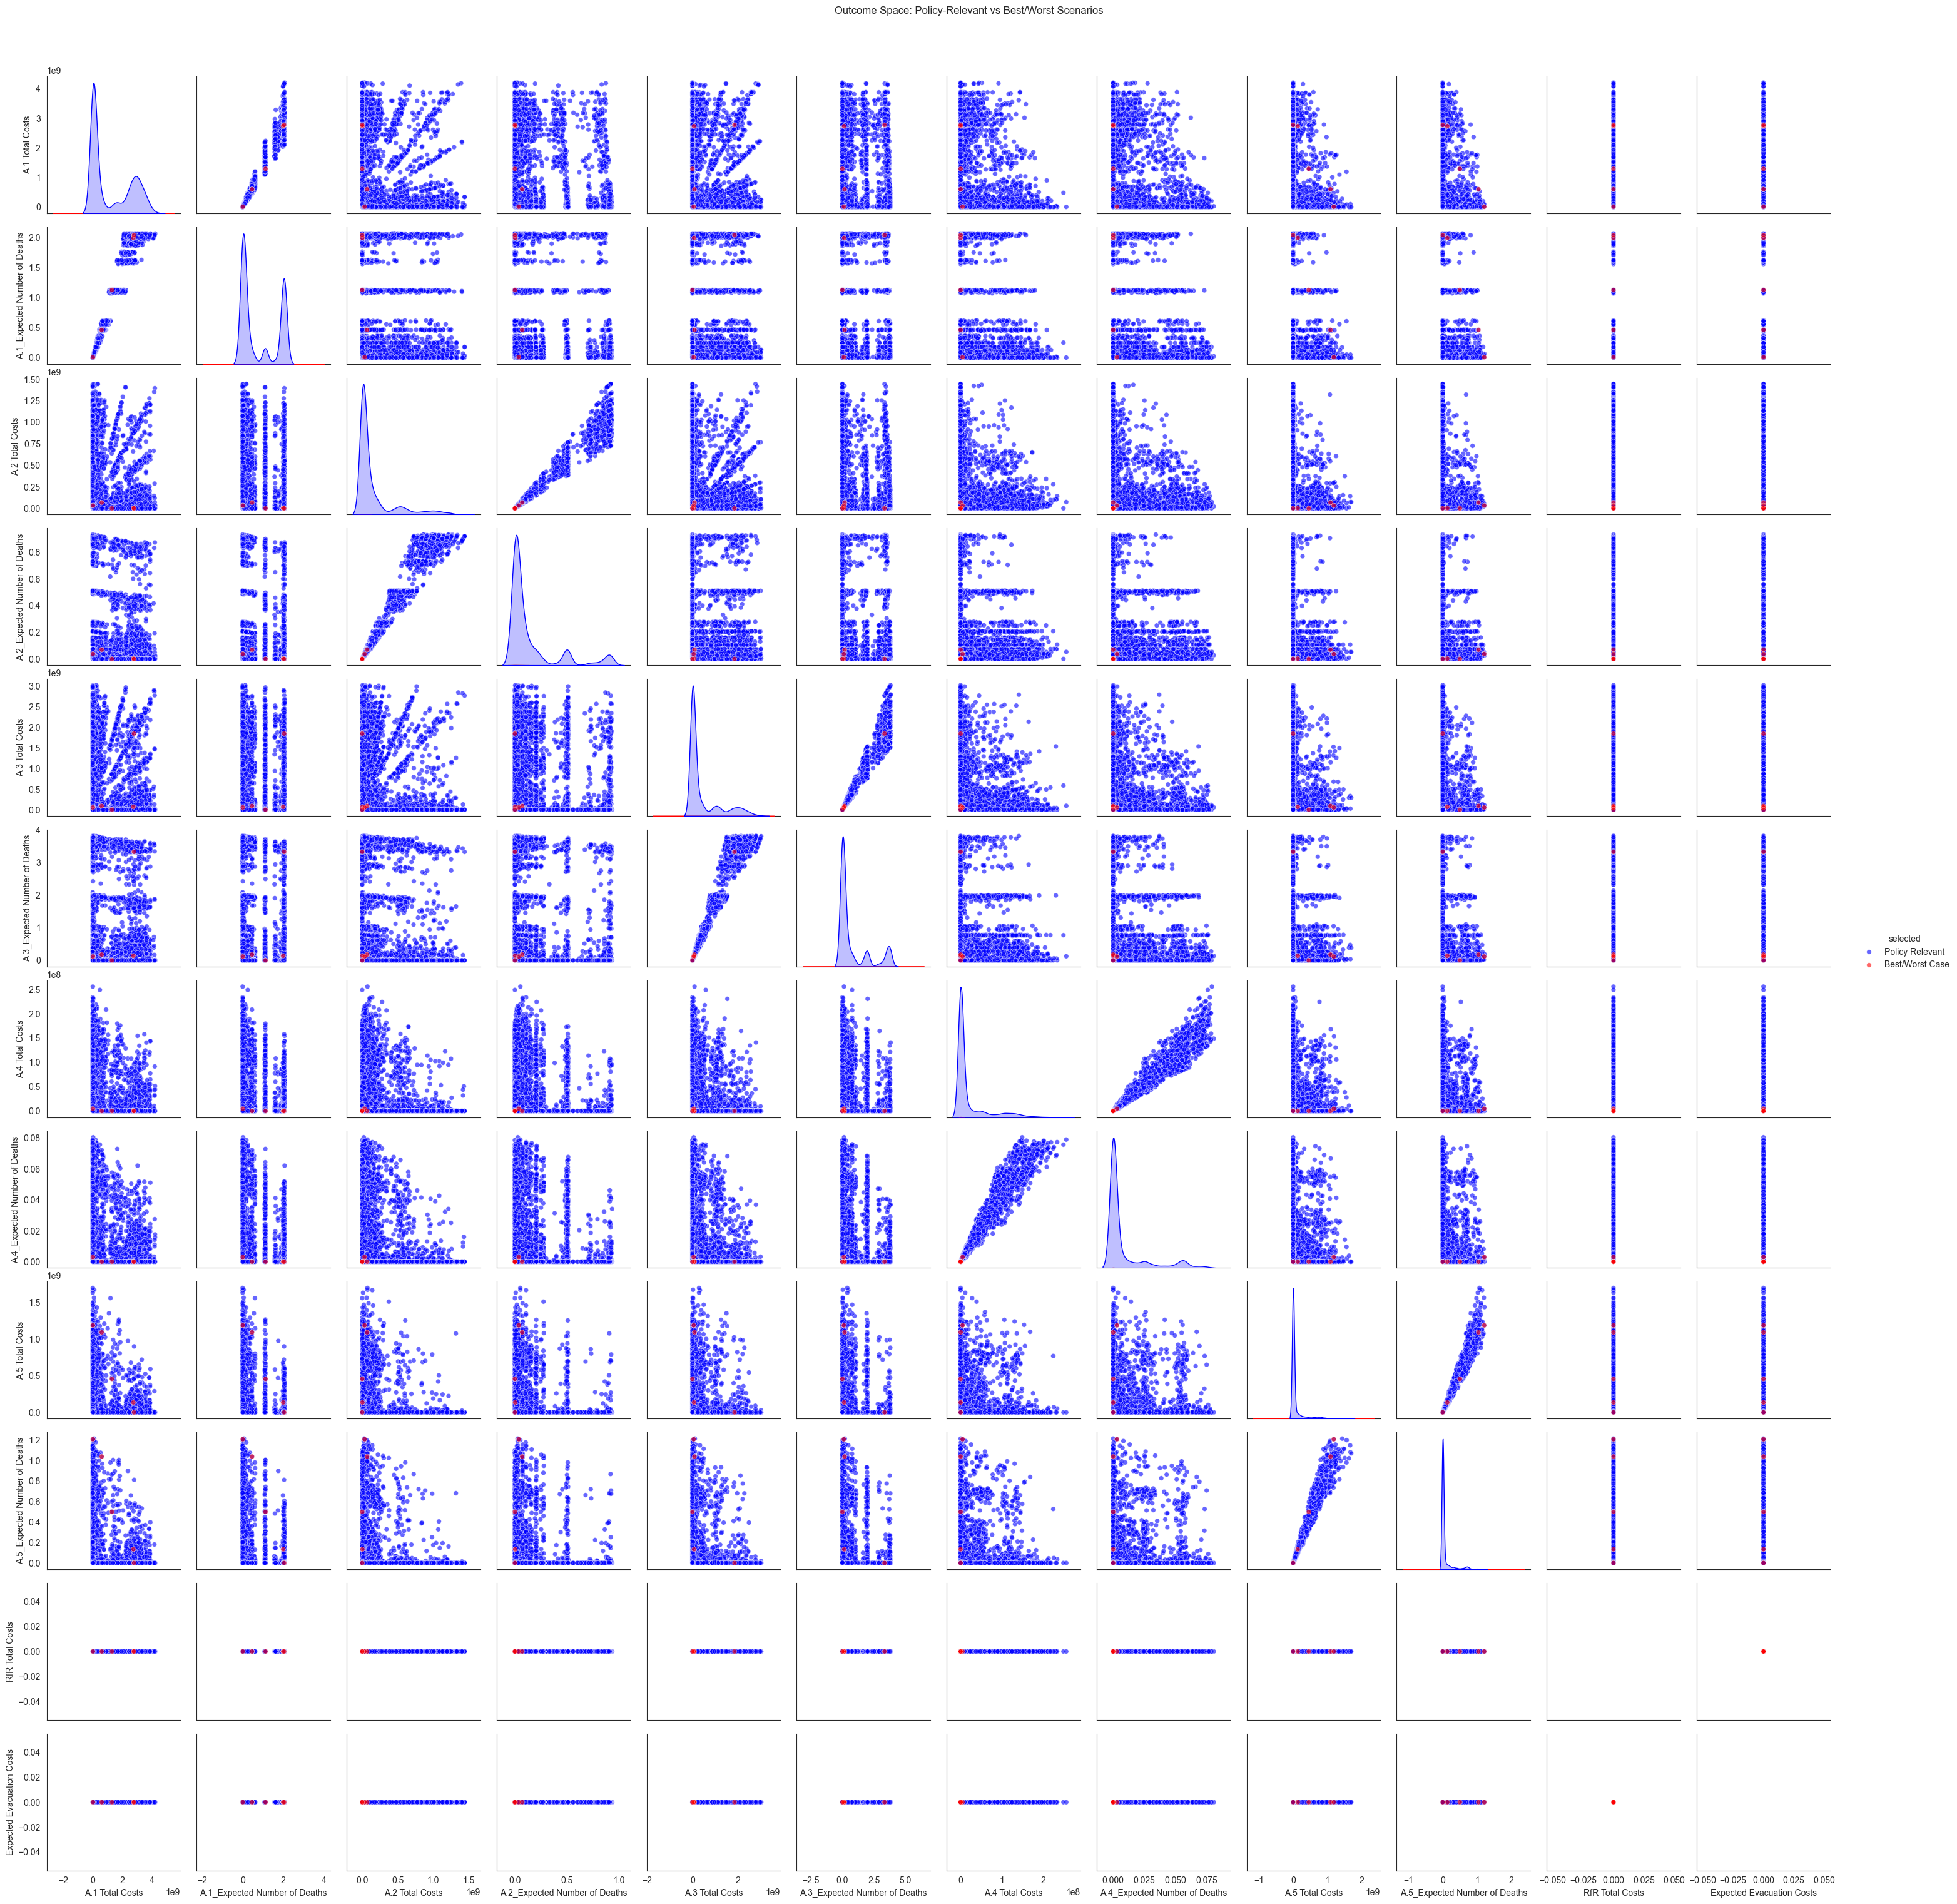

In [8]:
def plot_pairwise_outcomes(outcomes, mask, selected_ids):
    """
    Plot a pairplot comparing full outcome space with the selected (best/worst) scenarios.
    """
    full_df = pd.DataFrame({k: v[mask] for k, v in outcomes.items()})
    full_df['selected'] = 'Policy Relevant'

    highlighted = full_df.loc[selected_ids].copy()
    highlighted['selected'] = 'Best/Worst Case'

    combined = pd.concat([full_df, highlighted])

    sns.pairplot(
        combined,
        vars=full_df.columns.drop('selected'),
        hue='selected',
        palette={'Policy Relevant': 'blue', 'Best/Worst Case': 'red'},
        plot_kws={'alpha': 0.6, 's': 30}
    )
    plt.suptitle('Outcome Space: Policy-Relevant vs Best/Worst Scenarios', y=1.02)
    plt.show()


# Call the function
plot_pairwise_outcomes(outcomes, mask, selected_ids)


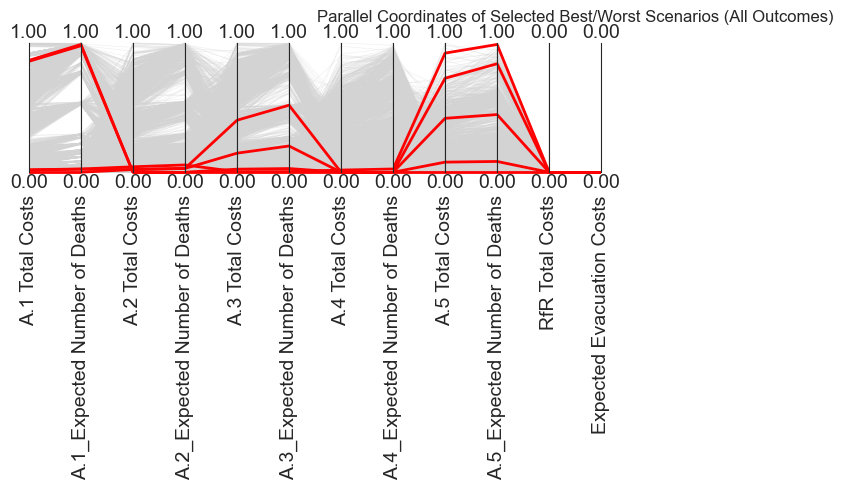

In [13]:
def plot_parallel_with_highlight(outcomes, mask, selected_ids):
    """
    Visualizes all policy-relevant outcomes and overlays selected scenarios.
    """
    all_outcomes = pd.DataFrame({k: v[mask] for k, v in outcomes.items()})
    norm_data = all_outcomes.copy()
    norm_data[:] = minmax_scale(norm_data)

    selected = norm_data.loc[selected_ids]

    limits = parcoords.get_limits(norm_data)
    ax = parcoords.ParallelAxes(limits)
    ax.plot(norm_data, color='lightgrey', lw=0.5, alpha=0.3)
    ax.plot(selected, color='red', lw=2)

    plt.title('Parallel Coordinates of Selected Best/Worst Scenarios (All Outcomes)')
    plt.show()


# Call the function
plot_parallel_with_highlight(outcomes, mask, selected_ids)


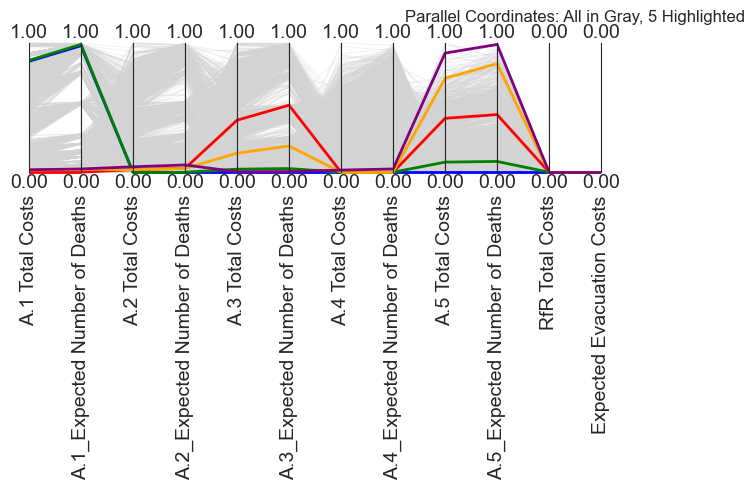

In [14]:
def plot_highlighted_individual_colors(outcomes, mask, selected_ids):
    """
    Same as previous, but each selected scenario gets a different color.
    """
    full_df = pd.DataFrame({k: v[mask] for k, v in outcomes.items()})
    norm_all = full_df.copy()
    norm_all[:] = minmax_scale(full_df)

    selected_rows = norm_all.loc[selected_ids]
    limits = parcoords.get_limits(norm_all)

    ax = parcoords.ParallelAxes(limits)
    ax.plot(norm_all, color='lightgray', lw=0.5, alpha=0.4)

    colors = ['red', 'blue', 'green', 'orange', 'purple']
    for i, (idx, row) in enumerate(selected_rows.iterrows()):
        ax.plot(row.to_frame().T, color=colors[i % len(colors)], lw=2)

    plt.title('Parallel Coordinates: All in Gray, 5 Highlighted')
    plt.show()


# Call the function
plot_highlighted_individual_colors(outcomes, mask, selected_ids)


In [8]:
# Utility functions for consistent variable naming (to comply with Platypus / optimization standards)

def clean_name(name, prefix="L_"):
    """
    Clean variable names for Platypus compatibility by removing special characters
    and adding a prefix if it starts with a digit.
    """
    clean = name.replace(" ", "_").replace(".", "_").replace("-", "_")
    if clean[0].isdigit():
        clean = prefix + clean
    return clean


def clean_column_names(df, prefix="L_"):
    """
    Apply clean_name to all column names in a DataFrame.
    """
    df = df.copy()
    df.columns = [clean_name(col, prefix=prefix) for col in df.columns]
    return df


# Define outcome objectives of interest
objectives_of_interest = [
    "A.5 Total Costs",
    "A.5_Expected Number of Deaths"]

cleaned_objectives_of_interest = [clean_name(o, "O_") for o in objectives_of_interest]


In [79]:
cleaned_objectives_of_interest

['A_5_Total_Costs', 'A_5_Expected_Number_of_Deaths']

In [9]:
# === Optimization function Kwakkel-style ===
import copy


def optimize_scenario(scenario, nfe, model, epsilons):
    # Create a deep copy of the model for problem definition
    import copy
    model_for_problem = copy.deepcopy(model)
    names_to_keep = []
    for o in model_for_problem.outcomes:
        if o.name in objectives_of_interest:
            names_to_keep.append(o.name)

    for name in list(model_for_problem.outcomes.keys()):
        if name not in names_to_keep:
            del model_for_problem.outcomes[name]

    # Clean names for problem definition
    for lever in model_for_problem.levers:
        lever.name = clean_name(lever.name, "L_")
    for outcome in model_for_problem.outcomes:
        outcome.name = clean_name(outcome.name, "O_")

    problem = to_problem(model_for_problem, searchover="levers")
    problem._outcome_names = cleaned_objectives_of_interest

    names_to_keep = []
    for o in model.outcomes:
        if o.name in objectives_of_interest:
            names_to_keep.append(o.name)

    for name in list(model.outcomes.keys()):
        if name not in names_to_keep:
            del model.outcomes[name]

    reference_scenario = scenario

    results = []
    convergences = []
    # problem is now created above from cleaned model

    lever_names = [clean_name(l.name, "L_") for l in model.levers]
    outcome_names = [clean_name(o.name, "O_") for o in model.outcomes]

    os.makedirs("./archives", exist_ok=True)

    with MultiprocessingEvaluator(model) as evaluator:
        for run_id in range(5):
            archive_filename = f"optimization3_{scenario.name}_run{run_id}.tar.gz"
            archive_path = f"./archives/{archive_filename}"
            if os.path.exists(archive_path):
                os.remove(archive_path)

            convergence_metrics = [
                ArchiveLogger("./archives", lever_names, outcome_names, base_filename=archive_filename),
                EpsilonProgress()
            ]

            print(f"🔁 Running optimization for scenario {scenario.name}, run {run_id}")
            result, convergence = evaluator.optimize(
                nfe=nfe,
                searchover='levers',
                convergence=convergence_metrics,
                epsilons=epsilons,
                reference=reference_scenario
            )

            result = clean_column_names(result)
            results.append(result)
            convergences.append(convergence)

            #archive_loaded = ArchiveLogger.load_archives(archive_path)
            #archive_cleaned = {k: clean_column_names(v) for k, v in archive_loaded.items()}
            #archive_path_clean = f"./archives/cleaned_{scenario.name}_run{run_id}.csv"
            #archive_cleaned[max(archive_cleaned.keys())].to_csv(archive_path_clean, index=False)
            #print(f"💾 Cleaned archive saved to {archive_path_clean}")

    # Optional: merge all results across 5 runs for the scenario
    reference_set = epsilon_nondominated(results, epsilons, problem)
    return reference_set, convergences


In [10]:
# Convert selected experiments into ema_workbench Scenario objects
scenarios = [
    Scenario(f"Scenario_{i}", **row.to_dict())
    for i, row in selected_experiments.iterrows()
]


In [108]:
epsilons = [1000000, 0.00001]
model, _ = get_model_for_problem_formulation(3)

# Run optimization for each selected scenario
optimization_results = []
for scenario in scenarios:
    optimization_results.append(optimize_scenario(scenario, 10000, model, epsilons))


[MainProcess/INFO] pool started with 8 workers


🔁 Running optimization for scenario Scenario_7284, run 0



 10%|███▋                                 | 100/1000 [10:01<1:30:15,  6.02s/it]

100%|████████████████████████████████████| 10000/10000 [08:39<00:00, 19.25it/s]
[MainProcess/INFO] optimization completed, found 1 solutions


🔁 Running optimization for scenario Scenario_7284, run 1


100%|████████████████████████████████████| 10000/10000 [08:42<00:00, 19.15it/s]
[MainProcess/INFO] optimization completed, found 1 solutions


...

100%|████████████████████████████████████| 10000/10000 [07:52<00:00, 21.15it/s]
[MainProcess/INFO] optimization completed, found 1 solutions


🔁 Running optimization for scenario Scenario_2927, run 3


100%|████████████████████████████████████| 10000/10000 [08:15<00:00, 20.19it/s]
[MainProcess/INFO] optimization completed, found 1 solutions


🔁 Running optimization for scenario Scenario_2927, run 4


100%|████████████████████████████████████| 10000/10000 [08:15<00:00, 20.17it/s]
[MainProcess/INFO] optimization completed, found 1 solutions
[MainProcess/INFO] terminating pool


In [150]:


# Save the full optimization result list (tuples of DataFrame + convergence)
with open("optimization_results3.pkl", "wb") as f:
    pickle.dump(optimization_results, f)


In [6]:
# Load previously saved optimization results
with open("optimization_results3.pkl", "rb") as f:
    optimization_results = pickle.load(f)


In [11]:
# Unpack the optimization results to extract all non-dominated solutions
all_results_df = pd.concat([df for df, _ in optimization_results])

# Detect max values per objective (used for calculating hypervolume bounds)
max_vals = all_results_df[cleaned_objectives_of_interest].max().tolist()

# Slightly extend upper bound to avoid boundary precision issues
max_vals[1] += 1e-10

print("Auto-detected HV max values:", max_vals)


Auto-detected HV max values: [44193513.54513965, 1e-10]


In [12]:
# Print number of non-dominated policies per scenario and total count
for i, (df, _) in enumerate(optimization_results):
    print(f"Scenario {i}: {len(df)} non-dominated solutions")

print(f"Total across all scenarios: {len(all_results_df)}")


Scenario 0: 1 non-dominated solutions
Scenario 1: 1 non-dominated solutions
Scenario 2: 1 non-dominated solutions
Scenario 3: 1 non-dominated solutions
Scenario 4: 1 non-dominated solutions
Total across all scenarios: 5


In [13]:
for obj in cleaned_objectives_of_interest:
    print(f"{obj}: min = {all_results_df[obj].min()}, max = {all_results_df[obj].max()}")


A_5_Total_Costs: min = 0.0, max = 44193513.54513965
A_5_Expected_Number_of_Deaths: min = 0.0, max = 0.0


In [26]:
from platypus import Hypervolume
from ema_workbench.em_framework.optimization import rebuild_platypus_population

dike_model, _ = get_model_for_problem_formulation(3)
def calculate_convergence_metrics(problem, archive_path, max_vals):
    hv = Hypervolume(minimum=[0] * len(cleaned_objectives_of_interest), maximum=max_vals)
    archives = ArchiveLogger.load_archives(archive_path)
    metrics = []
    for nfe, archive in archives.items():
        population = rebuild_platypus_population(archive, problem)
        metrics.append(dict(hypervolume=hv.calculate(population), nfe=nfe))
    df = pd.DataFrame(metrics)
    df.sort_values(by="nfe", inplace=True, ignore_index=True)
    return df


model_for_problem = copy.deepcopy(model)
names_to_keep = []
for o in model_for_problem.outcomes:
    if o.name in objectives_of_interest:
        names_to_keep.append(o.name)

for name in list(model_for_problem.outcomes.keys()):
    if name not in names_to_keep:
        del model_for_problem.outcomes[name]

# Clean names for problem definition
for lever in model_for_problem.levers:
    lever.name = clean_name(lever.name, "L_")
for outcome in model_for_problem.outcomes:
    outcome.name = clean_name(outcome.name, "O_")

problem = to_problem(model_for_problem, searchover="levers")
problem._outcome_names = cleaned_objectives_of_interest
convergence_calculations = []
for (refset, eps_progress), scenario in zip(optimization_results, scenarios):
    for seed, seed_eps in zip(range(5), eps_progress):
        archive_file = f"./archives/optimization3_{scenario.name}_run{seed}.tar.gz"
        metrics = calculate_convergence_metrics(problem, archive_file, max_vals)
        metrics["seed"] = seed
        metrics["scenario"] = scenario.name
        metrics["epsilon_progress"] = seed_eps.epsilon_progress

        convergence_calculations.append(metrics)
convergence = pd.concat(convergence_calculations, ignore_index=True)


<>:18: SyntaxWarning: invalid escape sequence '\e'
<>:18: SyntaxWarning: invalid escape sequence '\e'
/var/folders/64/05z9tvhd1mn8h92shl8zdmwr0000gn/T/ipykernel_1094/1441087784.py:18: SyntaxWarning: invalid escape sequence '\e'
  ax2.set_ylabel('$\epsilon$ progress')


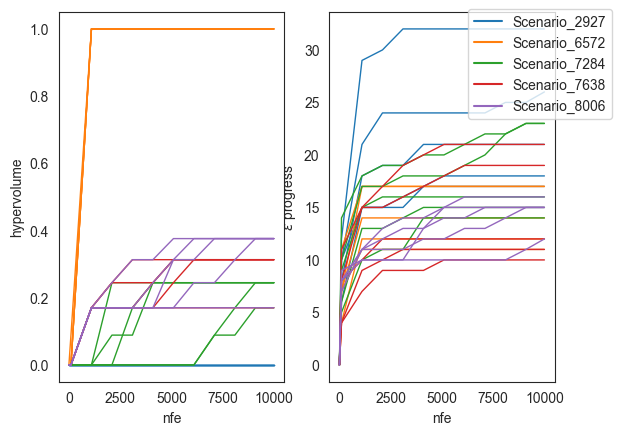

In [27]:
import matplotlib as mpl
import seaborn as sns

fig, (ax1, ax2) = plt.subplots(ncols=2)

colors = sns.color_palette()

legend_items = []
for (scenario_name, scores), color in zip(convergence.groupby("scenario"), colors):
    # we use this for a custom legend
    legend_items.append((mpl.lines.Line2D([0, 0], [1, 1], c=color), scenario_name))
    for seed, score in scores.groupby("seed"):
        ax1.plot(score.nfe, score.hypervolume, c=color, lw=1)
        ax2.plot(score.nfe, score.epsilon_progress, c=color, lw=1)

ax1.set_ylabel('hypervolume')
ax1.set_xlabel('nfe')
ax2.set_ylabel('$\epsilon$ progress')
ax2.set_xlabel('nfe')

# create our custom legend
artists, labels = zip(*legend_items)
fig.legend(artists, labels, bbox_to_anchor=(1, 0.9))

plt.show()

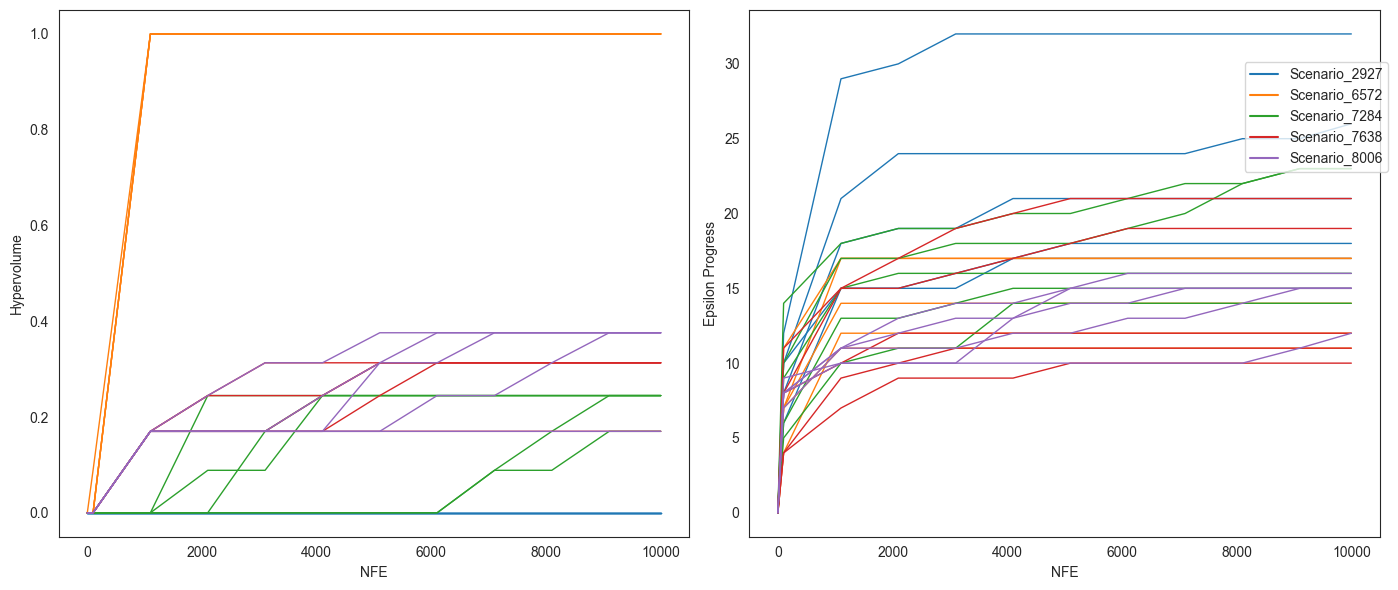

In [28]:
def plot_convergence(convergence_df):
    """
    Plot the convergence metrics for each scenario and optimization seed.

    Parameters:
        convergence_df (pd.DataFrame): DataFrame containing hypervolume and epsilon progress over NFE.
    """
    import matplotlib.pyplot as plt
    import matplotlib as mpl
    import seaborn as sns

    fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(14, 6))

    colors = sns.color_palette()
    legend_items = []

    for (scenario_name, scores), color in zip(convergence_df.groupby("scenario"), colors):
        legend_items.append((mpl.lines.Line2D([0, 0], [1, 1], c=color), scenario_name))

        for seed, score in scores.groupby("seed"):
            ax1.plot(score.nfe, score.hypervolume, c=color, lw=1)
            ax2.plot(score.nfe, score.epsilon_progress, c=color, lw=1)

    ax1.set_ylabel('Hypervolume')
    ax1.set_xlabel('NFE')
    ax2.set_ylabel('Epsilon Progress')
    ax2.set_xlabel('NFE')

    # Custom legend
    artists, labels = zip(*legend_items)
    fig.legend(artists, labels, bbox_to_anchor=(1.0, 0.9))
    plt.tight_layout()
    plt.show()


# Call the function to visualize convergence
plot_convergence(convergence)


In [18]:
from ema_workbench import Policy


def create_policy_objects_from_results(results):
    """
    Convert optimization results to EMA Policy objects.

    Parameters:
        results (list of tuples): Each tuple contains (reference set DataFrame, convergence metrics).

    Returns:
        list: A list of Policy objects created from the results.
    """
    policies = []
    for i, (result, _) in enumerate(results):
        result = result.iloc[:, 0:31]  # Assumes the first 31 columns are levers
        for j, row in result.iterrows():
            policy = Policy(f"scenario {i} option {j}", **row.to_dict())
            policies.append(policy)
    return policies


# Generate the policy objects
policies = create_policy_objects_from_results(optimization_results)


In [19]:


# Dictionary for renaming levers back to readable format
RENAME_MAP = {
    'L_0_RfR_0': '0_RfR 0', 'L_0_RfR_1': '0_RfR 1', 'L_0_RfR_2': '0_RfR 2',
    'L_1_RfR_0': '1_RfR 0', 'L_1_RfR_1': '1_RfR 1', 'L_1_RfR_2': '1_RfR 2',
    'L_2_RfR_0': '2_RfR 0', 'L_2_RfR_1': '2_RfR 1', 'L_2_RfR_2': '2_RfR 2',
    'L_3_RfR_0': '3_RfR 0', 'L_3_RfR_1': '3_RfR 1', 'L_3_RfR_2': '3_RfR 2',
    'L_4_RfR_0': '4_RfR 0', 'L_4_RfR_1': '4_RfR 1', 'L_4_RfR_2': '4_RfR 2',
    'EWS_DaysToThreat': 'EWS_DaysToThreat',
    'A_1_DikeIncrease_0': 'A.1_DikeIncrease 0', 'A_1_DikeIncrease_1': 'A.1_DikeIncrease 1',
    'A_1_DikeIncrease_2': 'A.1_DikeIncrease 2',
    'A_2_DikeIncrease_0': 'A.2_DikeIncrease 0', 'A_2_DikeIncrease_1': 'A.2_DikeIncrease 1',
    'A_2_DikeIncrease_2': 'A.2_DikeIncrease 2',
    'A_3_DikeIncrease_0': 'A.3_DikeIncrease 0', 'A_3_DikeIncrease_1': 'A.3_DikeIncrease 1',
    'A_3_DikeIncrease_2': 'A.3_DikeIncrease 2',
    'A_4_DikeIncrease_0': 'A.4_DikeIncrease 0', 'A_4_DikeIncrease_1': 'A.4_DikeIncrease 1',
    'A_4_DikeIncrease_2': 'A.4_DikeIncrease 2',
    'A_5_DikeIncrease_0': 'A.5_DikeIncrease 0', 'A_5_DikeIncrease_1': 'A.5_DikeIncrease 1',
    'A_5_DikeIncrease_2': 'A.5_DikeIncrease 2',
}


def rename_policy_levers(policies, rename_map=RENAME_MAP):
    """
    Rename the lever names in a list of Policy objects using a provided mapping.

    Parameters:
        policies (list of Policy): EMA Policy objects with cleaned lever names.
        rename_map (dict): Mapping of internal lever names to readable format.

    Returns:
        list: Policies with readable lever names.
    """
    renamed = []
    for i, policy in enumerate(policies):
        new_values = {rename_map.get(k, k): v for k, v in policy.items()}
        renamed.append(Policy(str(i), **new_values))
    return renamed


# Apply renaming
renamed_policies = rename_policy_levers(policies)


In [119]:



def reevaluate_policies(model, policies, n_scenarios=1000, save_path="reeevaluation_results.tar.gz"):
    """
    Evaluate a list of policies under a set number of uncertain scenarios.

    Parameters:
        model (Model): The EMA model instance.
        policies (list): List of Policy objects to evaluate.
        n_scenarios (int): Number of scenarios to simulate.
        save_path (str): File path to save results archive.

    Returns:
        tuple: (experiments, outcomes)
    """
    with MultiprocessingEvaluator(model) as evaluator:
        results = evaluator.perform_experiments(scenarios=n_scenarios, policies=policies)
    save_results(results, save_path)
    return results


# Reuse your dike_model here (assumed already defined above)
reeevaluation_results = reevaluate_policies(dike_model, renamed_policies)


[MainProcess/INFO] pool started with 8 workers
100%|██████████████████████████████████████| 5000/5000 [03:50<00:00, 21.69it/s]
[MainProcess/INFO] terminating pool
[MainProcess/INFO] results saved successfully to /Users/batuhantazegul/Documents/EPA/2425/Q4/EPA141A/aaaaaaa/final assignment/reeevaluation_results.tar.gz


In [20]:
def load_reeevaluation_results(file_path="reeevaluation_results.tar.gz"):
    """
    Load model results from a previously saved file.
    """
    return load_results(file_path)


# Load the results
reeevaluation_results= load_reeevaluation_results()

In [21]:
from ema_workbench import load_results
import numpy as np
import pandas as pd


def summarize_outcomes(results):
    """
    Create a summary DataFrame of outcome statistics (min, max, mean) for each outcome.

    Parameters:
        results (tuple): (experiments, outcomes) as returned by `perform_experiments`.

    Returns:
        pd.DataFrame: Transposed DataFrame with summary statistics.
    """
    _, outcomes = results
    summary = {
        name: {
            'min': np.min(values),
            'max': np.max(values),
            'mean': np.mean(values)
        }
        for name, values in outcomes.items()
    }
    return pd.DataFrame(summary).T


# Load reevaluation results if not already in memory
# experiments, outcomes = load_results("reeevaluation_results.tar.gz")
experiments, outcomes = reeevaluation_results

# Create and display summary
summary_df = summarize_outcomes(reeevaluation_results)
summary_df.head()


,min,max,mean
A.1 Total Costs,7.222271e+07,2.638174e+09,1.582675e+08
A.1_Expected Number of Deaths,0.000000e+00,1.919344e-01,9.144991e-04
A.2 Total Costs,0.000000e+00,1.188444e+09,1.436799e+08
A.2_Expected Number of Deaths,0.000000e+00,7.816521e-01,3.036942e-02
A.3 Total Costs,4.587651e+07,1.925834e+09,1.131188e+08


In [22]:
def calculate_acceptability(experiments, outcomes, thresholds):
    """
    Calculates the acceptability percentage for each policy based on thresholds.

    Parameters:
        experiments (DataFrame): Experiment metadata including policy assignments.
        outcomes (dict): Dictionary of outcomes with arrays of results.
        thresholds (dict): Acceptability thresholds per outcome.

    Returns:
        pd.DataFrame: Rows = policies, Columns = fraction of runs meeting each threshold.
    """
    overall_scores = {}

    for policy in experiments['policy'].unique():
        logical = experiments['policy'] == policy
        scores = {}

        for outcome_name, threshold in thresholds.items():
            n = np.sum(outcomes[outcome_name][logical] < threshold)
            scores[outcome_name] = n / logical.sum()  # Fraction passing

        overall_scores[policy] = scores

    return pd.DataFrame(overall_scores).T


# Set thresholds for A.5 and RfR outcomes
thresholds = {
    'A.5_Expected Number of Deaths': 1e-32,
    'A.5 Total Costs': 50_000_000,
}

# Evaluate acceptability
acceptability_df = calculate_acceptability(experiments, outcomes, thresholds)
acceptability_df.head()


,A.5_Expected Number of Deaths,A.5 Total Costs
0,0.971,0.979
1,0.124,0.666
2,0.939,0.968
3,0.918,0.951
4,0.997,0.997


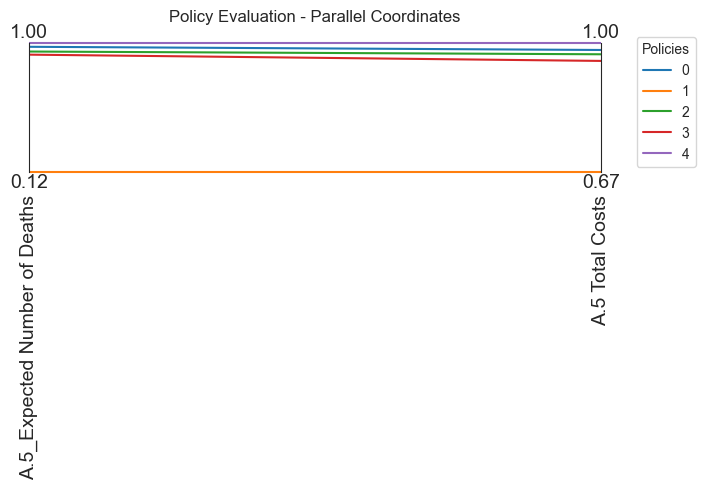

In [23]:
from ema_workbench.analysis import parcoords
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt


def plot_acceptability_parallel(acceptability_df):
    """
    Creates a parallel coordinate plot of the acceptability scores across policies.

    Parameters:
        acceptability_df (DataFrame): DataFrame of pass rates per policy and outcome.
    """
    limits = parcoords.get_limits(acceptability_df)
    paraxes = parcoords.ParallelAxes(limits)
    legend_handles = []

    colors = plt.cm.tab10.colors
    for i, policy in enumerate(acceptability_df.index):
        color = colors[i % len(colors)]
        paraxes.plot(acceptability_df.loc[[policy]], color=color)
        legend_handles.append(Line2D([0], [0], color=color, label=str(policy)))

    plt.legend(handles=legend_handles, title="Policies", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.title("Policy Evaluation - Parallel Coordinates")
    plt.show()


# Plot acceptability scores
plot_acceptability_parallel(acceptability_df)


In [29]:
def s_to_n(data, direction):
    """
    Calculate the signal-to-noise ratio for a set of outcome values.

    Parameters:
        data (array): Outcome values for a single policy.
        direction (ScalarOutcome): Whether the objective is to be minimized or maximized.

    Returns:
        float: The signal-to-noise score.
    """
    mean = np.mean(data)
    std = np.std(data)
    if std == 0:
        return 0
    return mean / std if direction == ScalarOutcome.MAXIMIZE else mean * std


def calculate_snr_scores(experiments, outcomes, dike_model):
    """
    Calculate S/N ratio for all policies and all outcomes.

    Parameters:
        experiments (DataFrame): EMA Workbench experiments.
        outcomes (dict): Dictionary of outcome arrays.
        dike_model (Model): Model object containing outcome definitions.

    Returns:
        DataFrame: Rows = policies, Columns = S/N scores per outcome.
    """
    overall_scores = {}
    for policy in experiments['policy'].unique():
        scores = {}
        logical = experiments['policy'] == policy

        for outcome in dike_model.outcomes:
            values = outcomes[outcome.name][logical]
            scores[outcome.name] = s_to_n(values, outcome.kind)

        overall_scores[policy] = scores

    return pd.DataFrame.from_dict(overall_scores).T


# Compute S/N ratios
snr_scores = calculate_snr_scores(experiments, outcomes, dike_model)
snr_scores.head()


,A.1 Total Costs,A.1_Expected Number of Deaths,A.2 Total Costs,A.2_Expected Number of Deaths,A.3 Total Costs,A.3_Expected Number of Deaths,A.4 Total Costs,A.4_Expected Number of Deaths,A.5 Total Costs,A.5_Expected Number of Deaths,RfR Total Costs,Expected Evacuation Costs
0,3.834796e+00,0.000000,2.490779e+16,0.000426,1.213289e+15,1.384995e-06,9.485291e+13,1.202215e-08,4.058808e+14,3.137805e-07,0.0,5.852072e+07
1,2.575234e+16,0.000049,9.407475e+15,0.000008,1.093603e+14,2.950785e-09,2.012678e+14,3.337574e-08,7.992833e+15,8.815867e-05,0.0,7.821850e+07
2,0.000000e+00,0.000000,2.490779e+16,0.018949,2.754967e+15,3.715488e-04,2.156263e+14,2.857272e-06,6.028255e+14,4.116879e-05,0.0,0.000000e+00
3,3.834796e+00,0.000000,3.707748e+16,0.000413,1.770603e+15,1.378759e-06,1.112891e+14,6.944160e-09,9.313541e+14,1.586142e-06,0.0,1.355133e+08
4,2.392348e+16,0.000020,2.463014e+16,0.000270,2.715780e+16,6.936582e-04,3.180790e+13,2.167555e-10,3.333726e+13,3.528336e-10,0.0,1.880679e+08


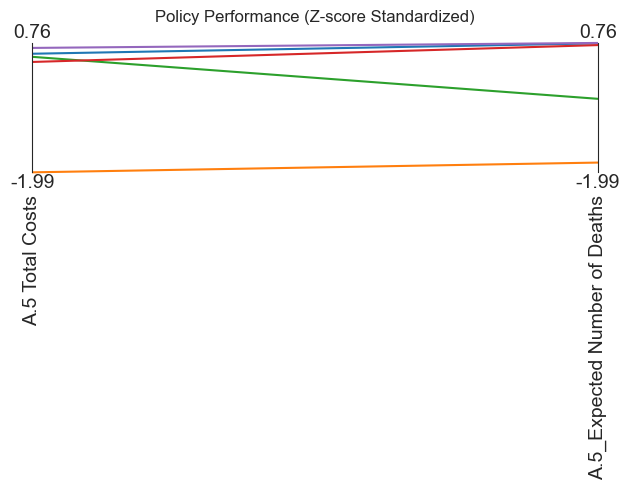

In [30]:
from sklearn.preprocessing import StandardScaler
from ema_workbench.analysis import parcoords
import matplotlib.pyplot as plt


def plot_standardized_snr(scores, selected_outcomes):
    """
    Plots the standardized signal-to-noise scores for selected outcomes.

    Parameters:
        scores (DataFrame): S/N ratio scores (policies x outcomes).
        selected_outcomes (list): List of outcome names to include in plot.
    """
    filtered = scores[selected_outcomes]
    scaler = StandardScaler()
    z_scores = pd.DataFrame(scaler.fit_transform(filtered), columns=filtered.columns, index=filtered.index)
    z_scores = -z_scores  # Flip: lower = better

    limits = parcoords.get_limits(z_scores)
    limits.loc[0, :] = z_scores.min().min()
    limits.loc[1, :] = z_scores.max().max()

    paraxes = parcoords.ParallelAxes(limits)
    for policy_name, row in z_scores.iterrows():
        paraxes.plot(row.to_frame().T, label=policy_name)

    plt.title("Policy Performance (Z-score Standardized)")
    plt.show()


# Select outcomes for A.5
selected_outcomes = ['A.5 Total Costs', 'A.5_Expected Number of Deaths']
plot_standardized_snr(snr_scores, selected_outcomes)


In [31]:
def calculate_regret(data):
    """
    Calculates regret as the difference between each policy's outcome
    and the best-performing (minimum) policy in the same scenario.

    Parameters:
        data (DataFrame): Pivoted DataFrame (scenarios x policies) for one outcome.

    Returns:
        DataFrame: Regret values (same shape as input).
    """
    best_per_scenario = data.min(axis=1).values[:, np.newaxis]
    regret = data - best_per_scenario
    return regret


def compute_max_regret_by_policy(dike_model, experiments, outcomes):
    """
    Computes the maximum regret for each policy and each outcome.

    Parameters:
        dike_model (Model): EMA model with outcomes.
        experiments (DataFrame): Simulation metadata.
        outcomes (dict): Dictionary of outcome arrays.

    Returns:
        DataFrame: Maximum regret values per policy and outcome.
    """
    overall_regret = {}
    max_regret = {}

    for outcome in dike_model.outcomes:
        outcome_name = outcome.name
        df = pd.DataFrame({
            outcome_name: outcomes[outcome_name],
            "policy": experiments['policy'],
            "scenario": experiments['scenario']
        })
        data = df.pivot(index='scenario', columns='policy', values=outcome_name)
        outcome_regret = calculate_regret(data)
        overall_regret[outcome_name] = outcome_regret
        max_regret[outcome_name] = outcome_regret.max()

    return pd.DataFrame(max_regret), overall_regret


# Compute regrets
max_regret_df, overall_regret = compute_max_regret_by_policy(dike_model, experiments, outcomes)

# Normalize for heatmap
normalized_regret_df = max_regret_df / max_regret_df.max()
normalized_regret_df.head()


,A.1 Total Costs,A.1_Expected Number of Deaths,A.2 Total Costs,A.2_Expected Number of Deaths,A.3 Total Costs,A.3_Expected Number of Deaths,A.4 Total Costs,A.4_Expected Number of Deaths,A.5 Total Costs,A.5_Expected Number of Deaths,RfR Total Costs,Expected Evacuation Costs
policy,,,,,,,,,,,,
0,0.022495,0.000000,0.885774,0.136565,0.142178,0.081100,0.709201,0.166826,0.212009,0.110654,1.000000,0.441152
1,1.000000,1.000000,0.232677,0.000000,0.043683,0.000000,1.000000,0.149879,1.000000,0.386956,0.269691,0.829660
2,0.073026,0.000000,0.885774,1.000000,0.265179,1.000000,0.664388,1.000000,0.292348,1.000000,0.523287,0.000000
3,0.022495,0.000000,1.000000,0.119484,0.184747,0.078464,0.418684,0.074416,0.363714,0.146776,0.054220,0.558761
4,0.458763,0.350848,0.885774,0.106091,1.000000,0.355526,0.230067,0.000000,0.047720,0.000000,0.000000,1.000000


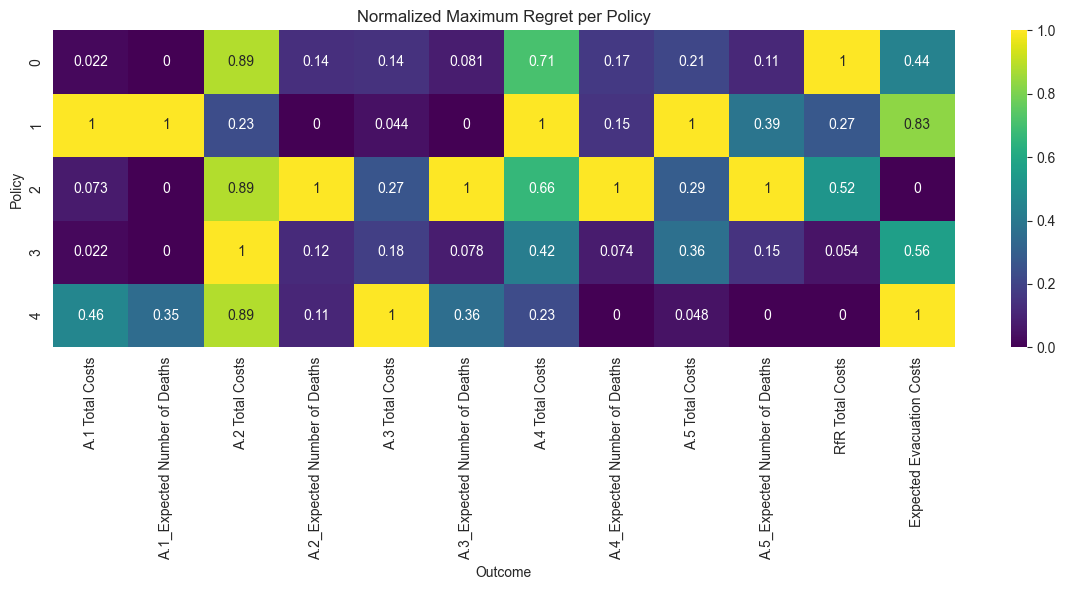

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns


def plot_regret_heatmap(normalized_regret_df, title="Normalized Maximum Regret per Policy"):
    """
    Generates a heatmap of normalized maximum regrets per policy.

    Parameters:
        normalized_regret_df (DataFrame): Normalized regret values.
        title (str): Title of the heatmap.
    """
    plt.figure(figsize=(12, 6))
    sns.heatmap(normalized_regret_df, annot=True, cmap="viridis")
    plt.title(title)
    plt.ylabel("Policy")
    plt.xlabel("Outcome")
    plt.tight_layout()
    plt.show()


# Plot all outcomes
plot_regret_heatmap(normalized_regret_df)


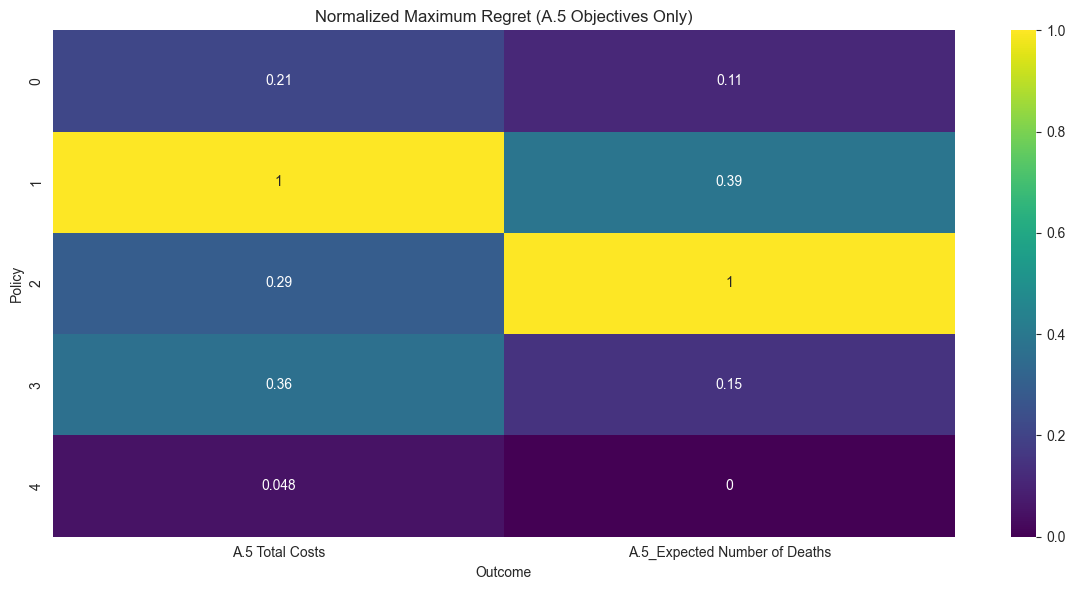

In [33]:
def plot_filtered_regret_heatmap(normalized_regret_df, selected_outcomes):
    """
    Plots heatmap for a selected subset of outcomes.

    Parameters:
        normalized_regret_df (DataFrame): Full regret data.
        selected_outcomes (list): Outcomes to include in heatmap.
    """
    filtered_regret_df = normalized_regret_df[selected_outcomes]
    plot_regret_heatmap(filtered_regret_df, title="Normalized Maximum Regret (A.5 Objectives Only)")


# A.5-focused regret
a5_objectives = ['A.5 Total Costs', 'A.5_Expected Number of Deaths']
plot_filtered_regret_heatmap(normalized_regret_df, a5_objectives)


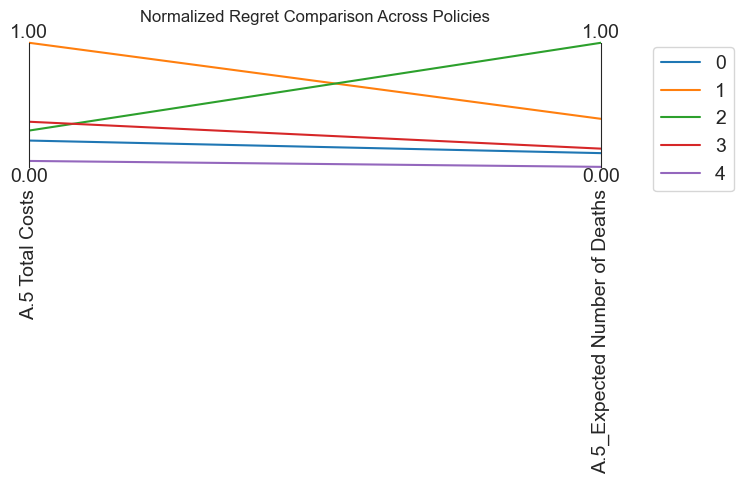

In [34]:
from ema_workbench.analysis import parcoords


def plot_parallel_regret_lines(data, selected_outcomes):
    """
    Plots a parallel coordinates plot for selected regret outcomes.

    Parameters:
        data (DataFrame): Normalized regret data.
        selected_outcomes (list): List of outcomes to include in the plot.
    """
    data = data[selected_outcomes]
    limits = parcoords.get_limits(data)
    limits.loc[0, selected_outcomes] = 0

    paraxes = parcoords.ParallelAxes(limits)
    for i, (index, row) in enumerate(data.iterrows()):
        paraxes.plot(row.to_frame().T, label=str(index), color=sns.color_palette()[i % 10])

    paraxes.legend()
    plt.title("Normalized Regret Comparison Across Policies")
    plt.show()


# Plot
plot_parallel_regret_lines(normalized_regret_df, a5_objectives)


In [35]:
from collections import defaultdict


def prepare_regret_by_policy(overall_regret):
    """
    Rearranges overall regret dict into a nested dict: {policy: {outcome: series}}.

    Parameters:
        overall_regret (dict): Full regret data.

    Returns:
        dict: Policy-structured regret dictionary.
    """
    policy_regret = defaultdict(dict)
    for outcome, df in overall_regret.items():
        for policy in df.columns:
            policy_regret[policy][outcome] = df[policy]
    return policy_regret


policy_regret = prepare_regret_by_policy(overall_regret)


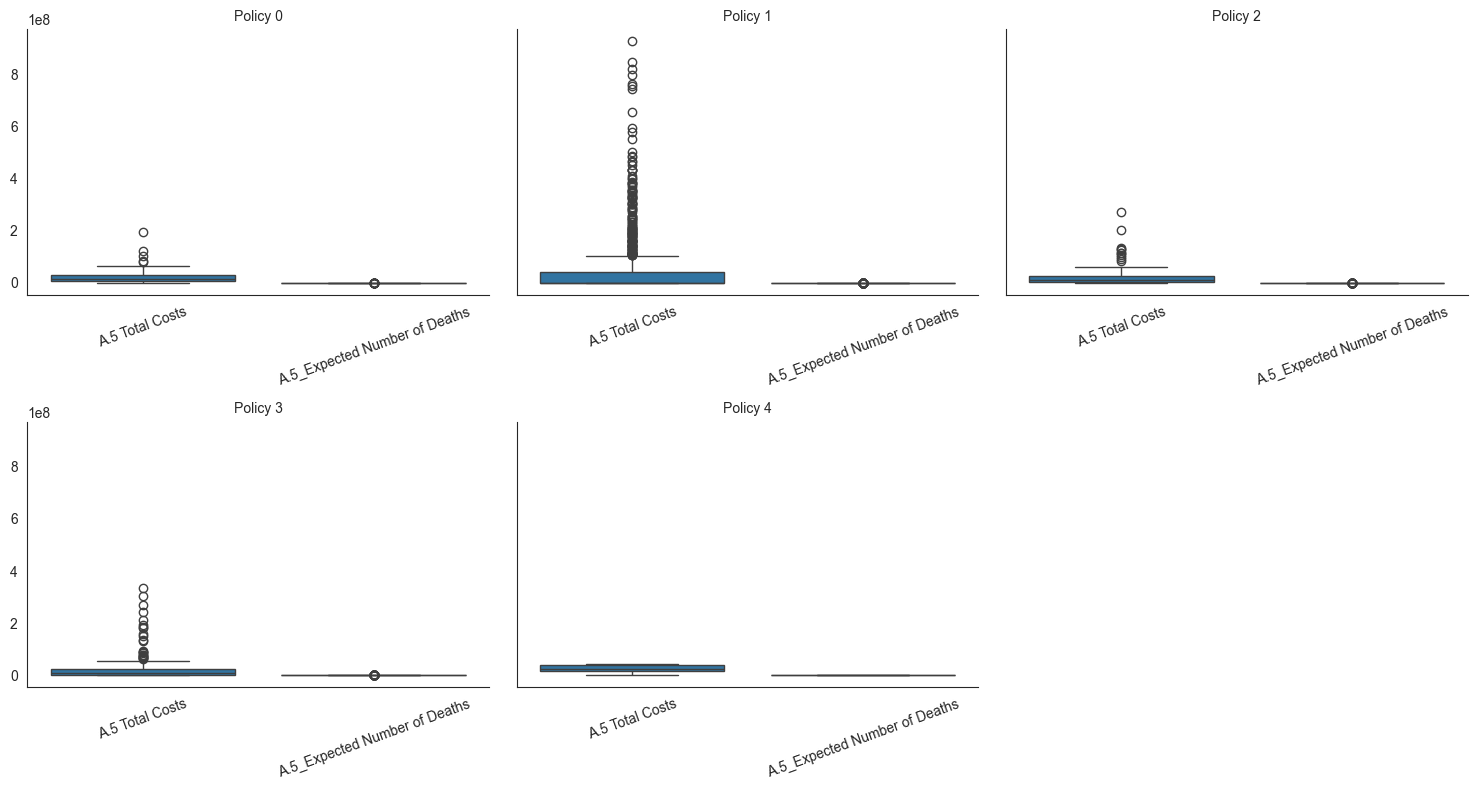

In [36]:
def plot_regret_boxplots(policy_regret, selected_outcomes):
    """
    Plots boxplots of regret per outcome per policy.

    Parameters:
        policy_regret (dict): Regret per policy/outcome.
        selected_outcomes (list): Outcomes to include.
    """
    num_policies = len(policy_regret)
    ncols = 3
    nrows = int(np.ceil(num_policies / ncols))

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, nrows * 4), sharey=True)
    axes = axes.flatten()

    for ax, (policy, regrets) in zip(axes, policy_regret.items()):
        data = pd.DataFrame(regrets)[selected_outcomes]
        sns.boxplot(data=data, ax=ax)
        ax.set_title(f"Policy {policy}", fontsize=10)
        ax.tick_params(axis='x', labelrotation=20)
        sns.despine()

    for ax in axes[len(policy_regret):]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.show()


# Display
plot_regret_boxplots(policy_regret, a5_objectives)


/var/folders/64/05z9tvhd1mn8h92shl8zdmwr0000gn/T/ipykernel_1094/208992550.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  policy_means = outcomes_df.groupby("policy").mean(numeric_only=True)


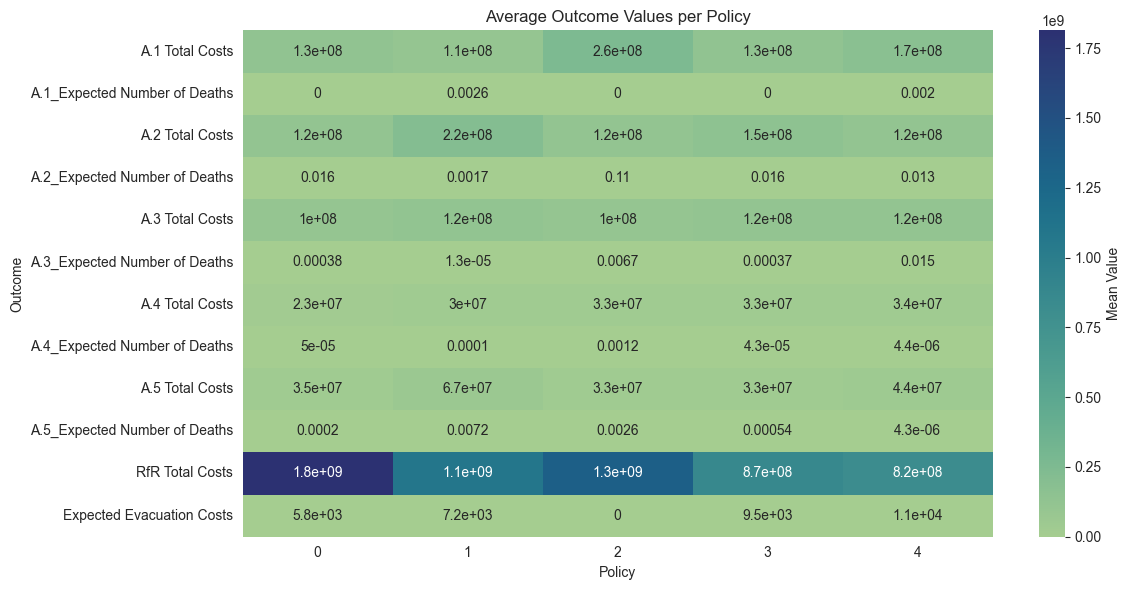

In [37]:
def plot_policy_means(outcomes, experiments):
    """
    Computes and plots the mean value of each outcome per policy.

    Parameters:
        outcomes (dict): Outcome arrays.
        experiments (DataFrame): Experiment metadata (contains 'policy').
    """
    outcomes_df = pd.DataFrame(outcomes)
    outcomes_df["policy"] = experiments["policy"]
    policy_means = outcomes_df.groupby("policy").mean(numeric_only=True)

    plt.figure(figsize=(12, 6))
    sns.heatmap(policy_means.T, annot=True, cmap="crest", cbar_kws={"label": "Mean Value"})
    plt.title("Average Outcome Values per Policy")
    plt.xlabel("Policy")
    plt.ylabel("Outcome")
    plt.tight_layout()
    plt.show()


# Call function
plot_policy_means(outcomes, experiments)


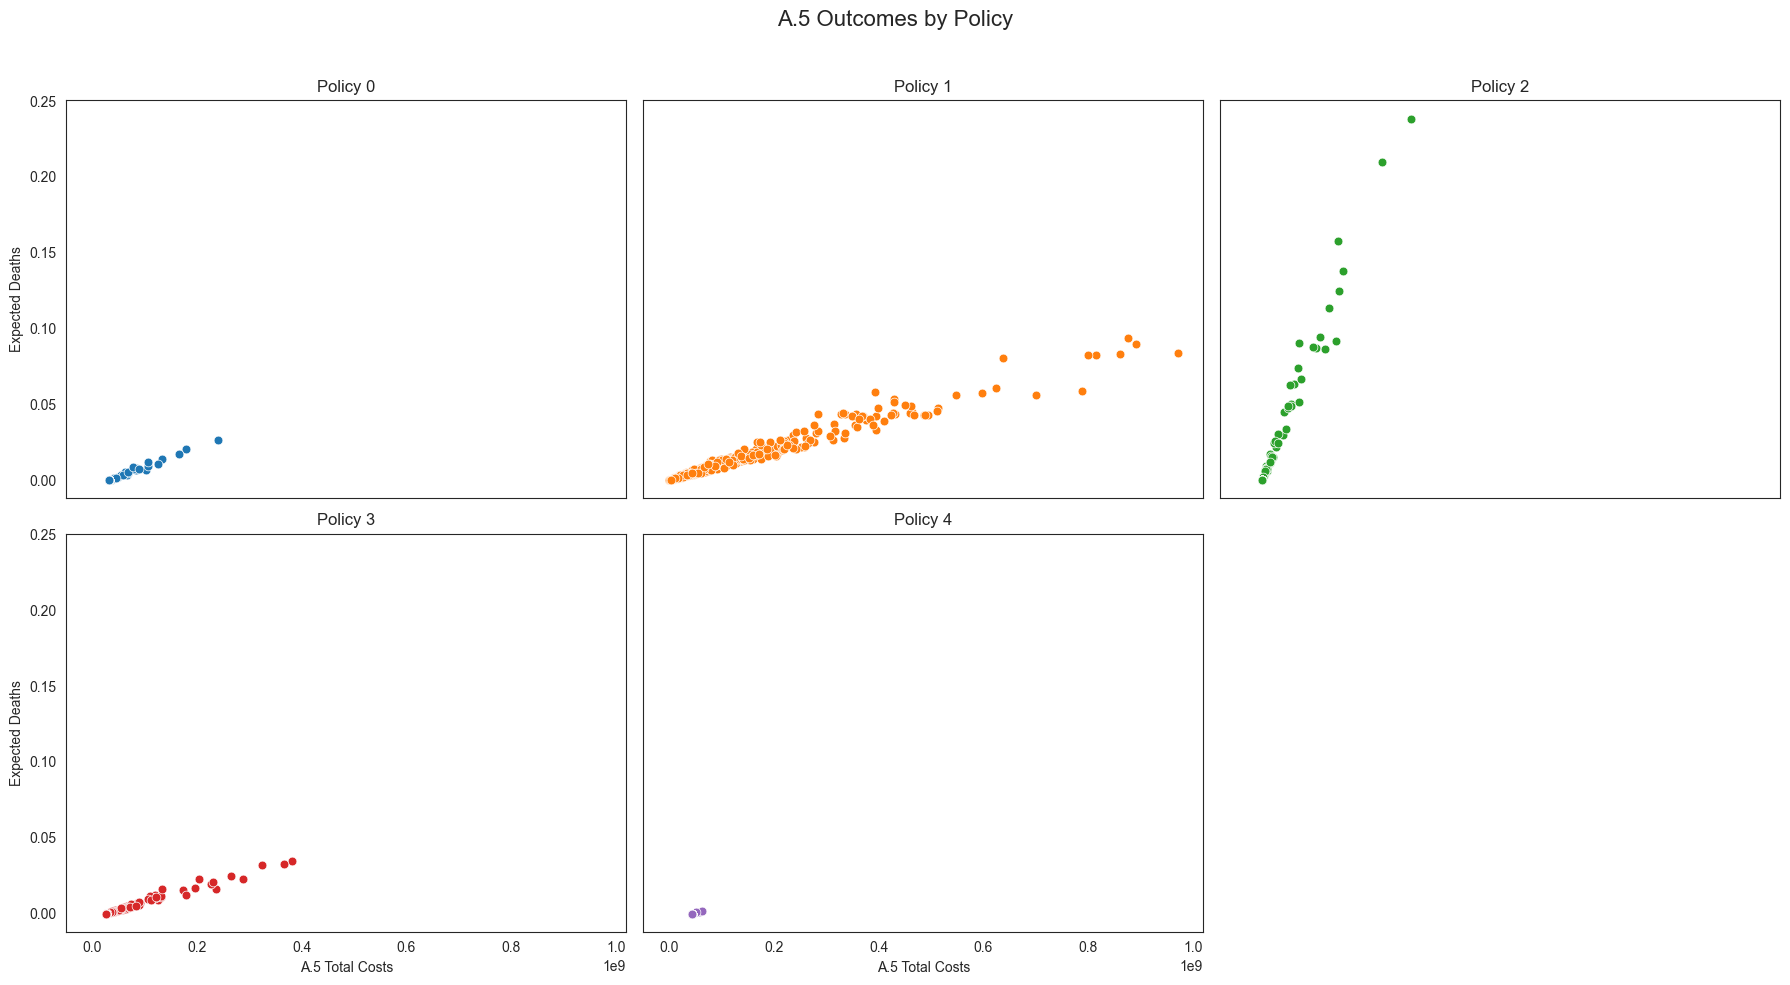

In [45]:
def plot_policy_scatter_grid(outcomes, experiments):
    """
    Creates scatter plots of total cost vs expected deaths per policy.

    Parameters:
        outcomes (dict): Simulation outcomes.
        experiments (DataFrame): Associated policy labels.
    """
    import math

    df = pd.DataFrame({
        "A.5 Total Costs": outcomes["A.5 Total Costs"],
        "A.5_Expected Number of Deaths": outcomes["A.5_Expected Number of Deaths"],
        "Policy": experiments["policy"].astype(str)
    })

    policies = df["Policy"].unique()
    n_policies = len(policies)
    ncols = 3
    nrows = math.ceil(n_policies / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows), sharex=True, sharey=True)
    axes = axes.flatten()

    for i, policy in enumerate(policies):
        ax = axes[i]
        subset = df[df["Policy"] == policy]
        sns.scatterplot(
            data=subset,
            x="A.5 Total Costs",
            y="A.5_Expected Number of Deaths",
            ax=ax,
            color=sns.color_palette("tab10")[i % 10],
            s=40, edgecolor="w", linewidth=0.5
        )
        ax.set_title(f"Policy {policy}")
        ax.set_xlabel("A.5 Total Costs")
        ax.set_ylabel("Expected Deaths")

    # Hide any unused axes
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle("A.5 Outcomes by Policy", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


# Run the scatter grid
plot_policy_scatter_grid(outcomes, experiments)


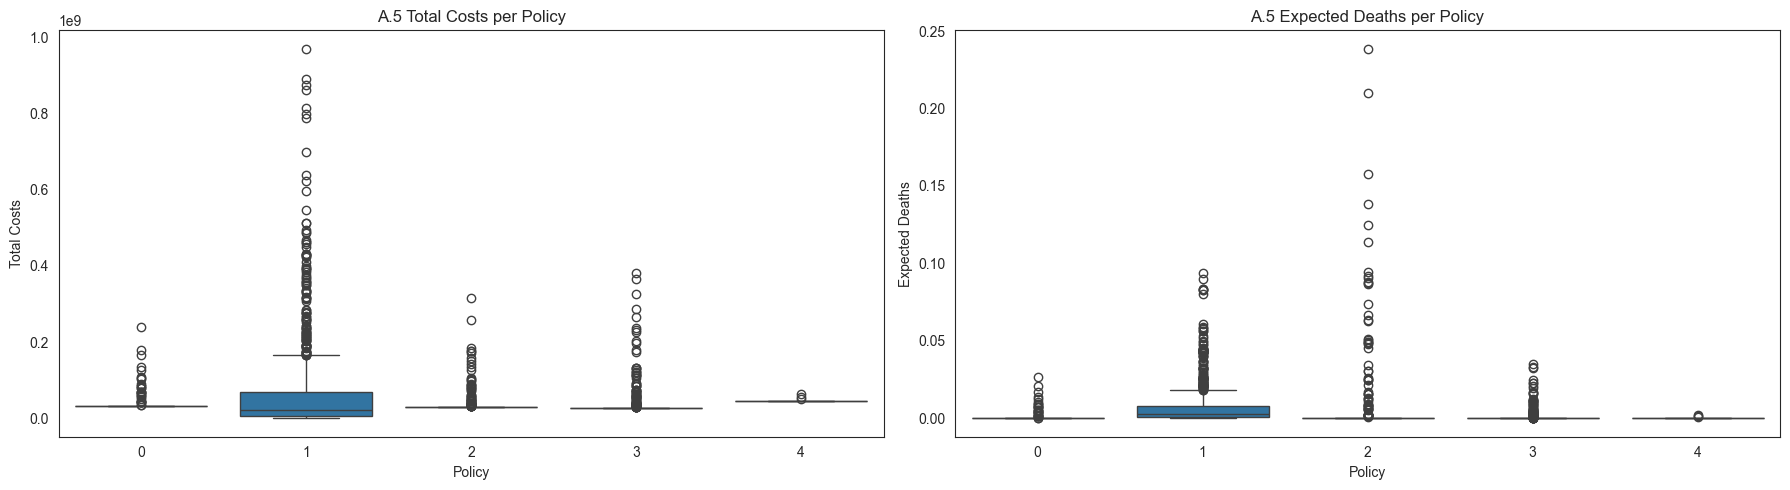

In [39]:
def plot_all_boxplots(outcomes, experiments):
    """
    Creates side-by-side boxplots for all key outcomes per policy.

    Parameters:
        outcomes (dict): Dictionary of outcome arrays.
        experiments (DataFrame): Experiment metadata.
    """
    df = pd.DataFrame({
        "A.5 Total Costs": outcomes["A.5 Total Costs"],
        "A.5_Expected Number of Deaths": outcomes["A.5_Expected Number of Deaths"],
        "RfR Total Costs": outcomes["RfR Total Costs"],
        "Policy": experiments["policy"].astype(str)
    })

    fig, axes = plt.subplots(1, 2, figsize=(18, 5), sharex=False)

    sns.boxplot(data=df, x='Policy', y='A.5 Total Costs', ax=axes[0])
    axes[0].set_title("A.5 Total Costs per Policy")
    axes[0].set_xlabel("Policy")
    axes[0].set_ylabel("Total Costs")

    sns.boxplot(data=df, x='Policy', y='A.5_Expected Number of Deaths', ax=axes[1])
    axes[1].set_title("A.5 Expected Deaths per Policy")
    axes[1].set_xlabel("Policy")
    axes[1].set_ylabel("Expected Deaths")



    plt.tight_layout()
    plt.show()


# Call the plotting function
plot_all_boxplots(outcomes, experiments)


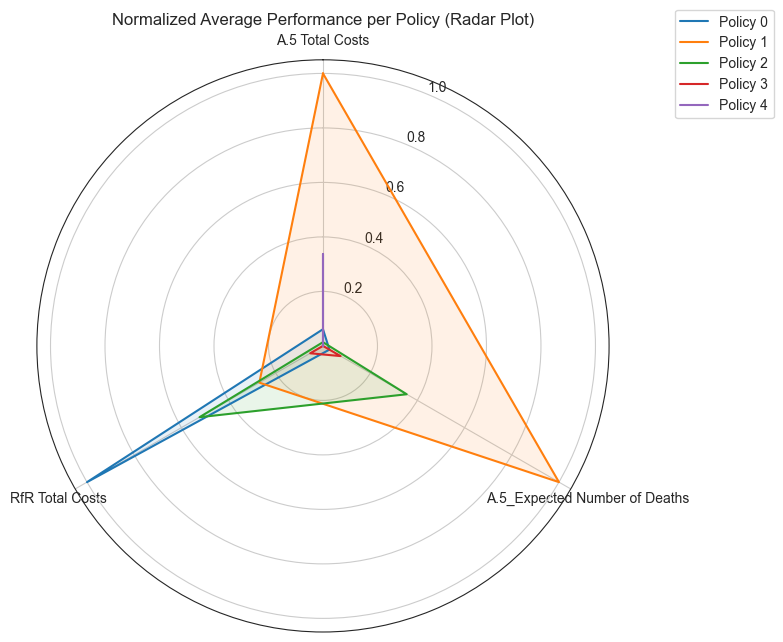

In [40]:
from math import pi


def plot_radar(outcomes, experiments):
    """
    Generates a radar plot for average normalized performance of each policy.

    Parameters:
        outcomes (dict): Dictionary of outcome arrays.
        experiments (DataFrame): Metadata including policy labels.
    """
    df = pd.DataFrame({
        "A.5 Total Costs": outcomes["A.5 Total Costs"],
        "A.5_Expected Number of Deaths": outcomes["A.5_Expected Number of Deaths"],
        "RfR Total Costs": outcomes["RfR Total Costs"],
        "Policy": experiments["policy"].astype(str)
    })

    avg = df.groupby("Policy")[
        ["A.5 Total Costs", "A.5_Expected Number of Deaths", "RfR Total Costs"]
    ].mean()

    norm = (avg - avg.min()) / (avg.max() - avg.min())

    labels = norm.columns.tolist()
    angles = [n / float(len(labels)) * 2 * pi for n in range(len(labels))]
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

    for idx, row in norm.iterrows():
        values = row.tolist() + row.tolist()[:1]
        ax.plot(angles, values, label=f"Policy {idx}")
        ax.fill(angles, values, alpha=0.1)

    ax.set_theta_offset(pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels)
    plt.title("Normalized Average Performance per Policy (Radar Plot)")
    plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    plt.tight_layout()
    plt.show()


# Show radar plot
plot_radar(outcomes, experiments)


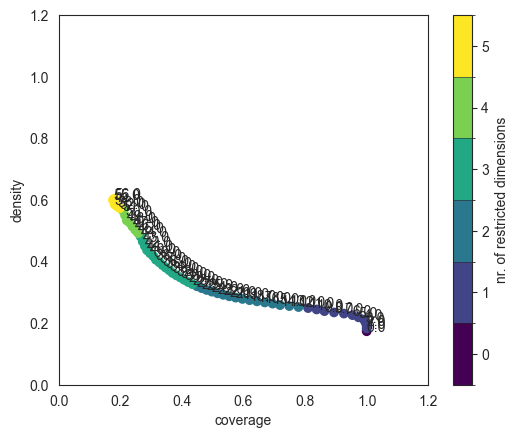

In [41]:
from ema_workbench.analysis import prim

# Define the outcome of interest and the threshold for "bad" performance
target_outcome = 'A.5_Expected Number of Deaths'
death_threshold = 0.001  # adjust as needed (e.g., anything >0.001 might be considered undesirable)

# Define the binary target variable for PRIM (1 = bad outcome)
y = outcomes[target_outcome] > death_threshold

# Drop all policy levers (keep only uncertainties for PRIM)
# You may want to customize this based on how your model defines uncertainties
lever_prefixes = ['0_RfR', '1_RfR', '2_RfR', '3_RfR', '4_RfR',  # RfR levers
                  'A.1_DikeIncrease', 'A.2_DikeIncrease', 'A.3_DikeIncrease', 'A.4_DikeIncrease', 'A.5_DikeIncrease',
                  'EWS_DaysToThreat']

# Drop the policy name and all lever columns
x = experiments.copy()
x = x.drop(columns=['policy'], errors='ignore')
x = x[[col for col in x.columns if not any(col.startswith(prefix) for prefix in lever_prefixes)]]

# Run PRIM
prim_alg = prim.Prim(x, y, threshold=0.5)
box = prim_alg.find_box()
box.show_tradeoff(annotated=True)
plt.show()


In [48]:
point = 27
box.inspect(point)

coverage       0.449309
density        0.319672
id            27.000000
k            390.000000
mass           0.244000
mean           0.319672
n           1220.000000
res_dim        2.000000
Name: 27, dtype: float64

             box 27                                 
                min       max qp value      qp value
A.5_pfail  0.000442  0.254672      NaN  9.131187e-34
A.1_pfail  0.049960  0.999579  0.49713           NaN



[None]

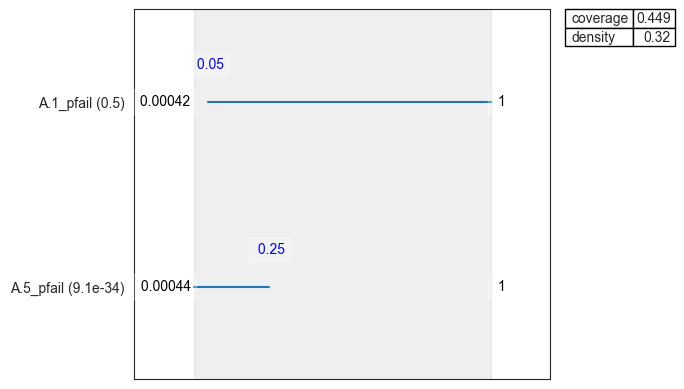

In [49]:
box.inspect(point, style='graph')
plt.show()

In [143]:
import pandas as pd

# Combine all decision variables from each scenario into one table
optimized_policies = []

for i, (df, _) in enumerate(optimization_results):
    df = df.copy()
    df["Scenario"] = f"Scenario {i}"
    df["Policy"] = [f"Policy {i}_{j}" for j in range(len(df))]
    optimized_policies.append(df)

# Combine into single DataFrame
all_policies_df = pd.concat(optimized_policies, ignore_index=True)

# Select just the levers (first 30–35 columns, usually), adjust as needed
lever_columns = [col for col in all_policies_df.columns if col.startswith("L_") or "Dike" in col or "RfR" in col or "EWS" in col]
policy_table = all_policies_df[["Policy", "Scenario"] + lever_columns]

# Save to Excel or show in report
policy_table.to_excel("optimized_policies.xlsx", index=False)


In [144]:
policy_table

,Policy,Scenario,L_0_RfR_0,L_0_RfR_1,L_0_RfR_2,L_1_RfR_0,L_1_RfR_1,L_1_RfR_2,L_2_RfR_0,L_2_RfR_1,...,A_2_DikeIncrease_2,A_3_DikeIncrease_0,A_3_DikeIncrease_1,A_3_DikeIncrease_2,A_4_DikeIncrease_0,A_4_DikeIncrease_1,A_4_DikeIncrease_2,A_5_DikeIncrease_0,A_5_DikeIncrease_1,A_5_DikeIncrease_2
0,Policy 0_0,Scenario 0,1,1,1,1,1,1,1,0,...,0,5,4,5,2,2,1,4,0,0
1,Policy 1_0,Scenario 1,0,0,1,0,1,0,1,0,...,6,9,2,8,2,1,6,0,0,0
2,Policy 2_0,Scenario 2,1,1,1,0,1,1,0,1,...,0,4,7,2,0,7,6,3,0,0
3,Policy 3_0,Scenario 3,1,1,1,0,0,0,0,0,...,0,6,7,5,2,7,2,2,0,0
4,Policy 4_0,Scenario 4,1,1,0,0,0,0,0,0,...,0,0,2,2,5,4,3,7,0,0


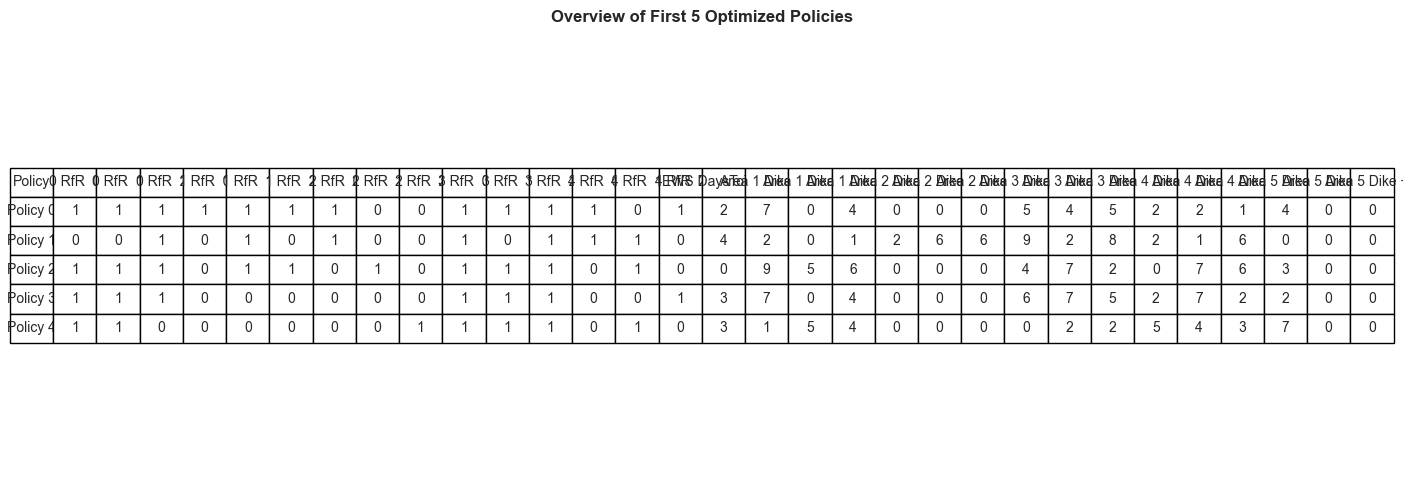

In [148]:
import pandas as pd

# Load the Excel file
df = pd.read_excel("./optimized_policies.xlsx")

# Select and rename relevant columns for clarity
display_columns = ["Policy",] + [col for col in df.columns if col.startswith(("L_", "A_", "EWS"))]
df_cleaned = df[display_columns]

# Rename levers to a readable format (optional)
df_cleaned.columns = [col.replace("_", " ").replace("L ", "").replace("A ", "Area ").replace("RfR", "RfR ").replace("DikeIncrease", "Dike +") for col in df_cleaned.columns]

# Format as a nice table
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 5))
ax.axis("off")
tbl = ax.table(cellText=df_cleaned.head(5).values,
               colLabels=df_cleaned.columns,
               cellLoc="center",
               loc="center")

tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.5)
plt.title("Overview of First 5 Optimized Policies", fontweight="bold")
plt.tight_layout()
plt.show()


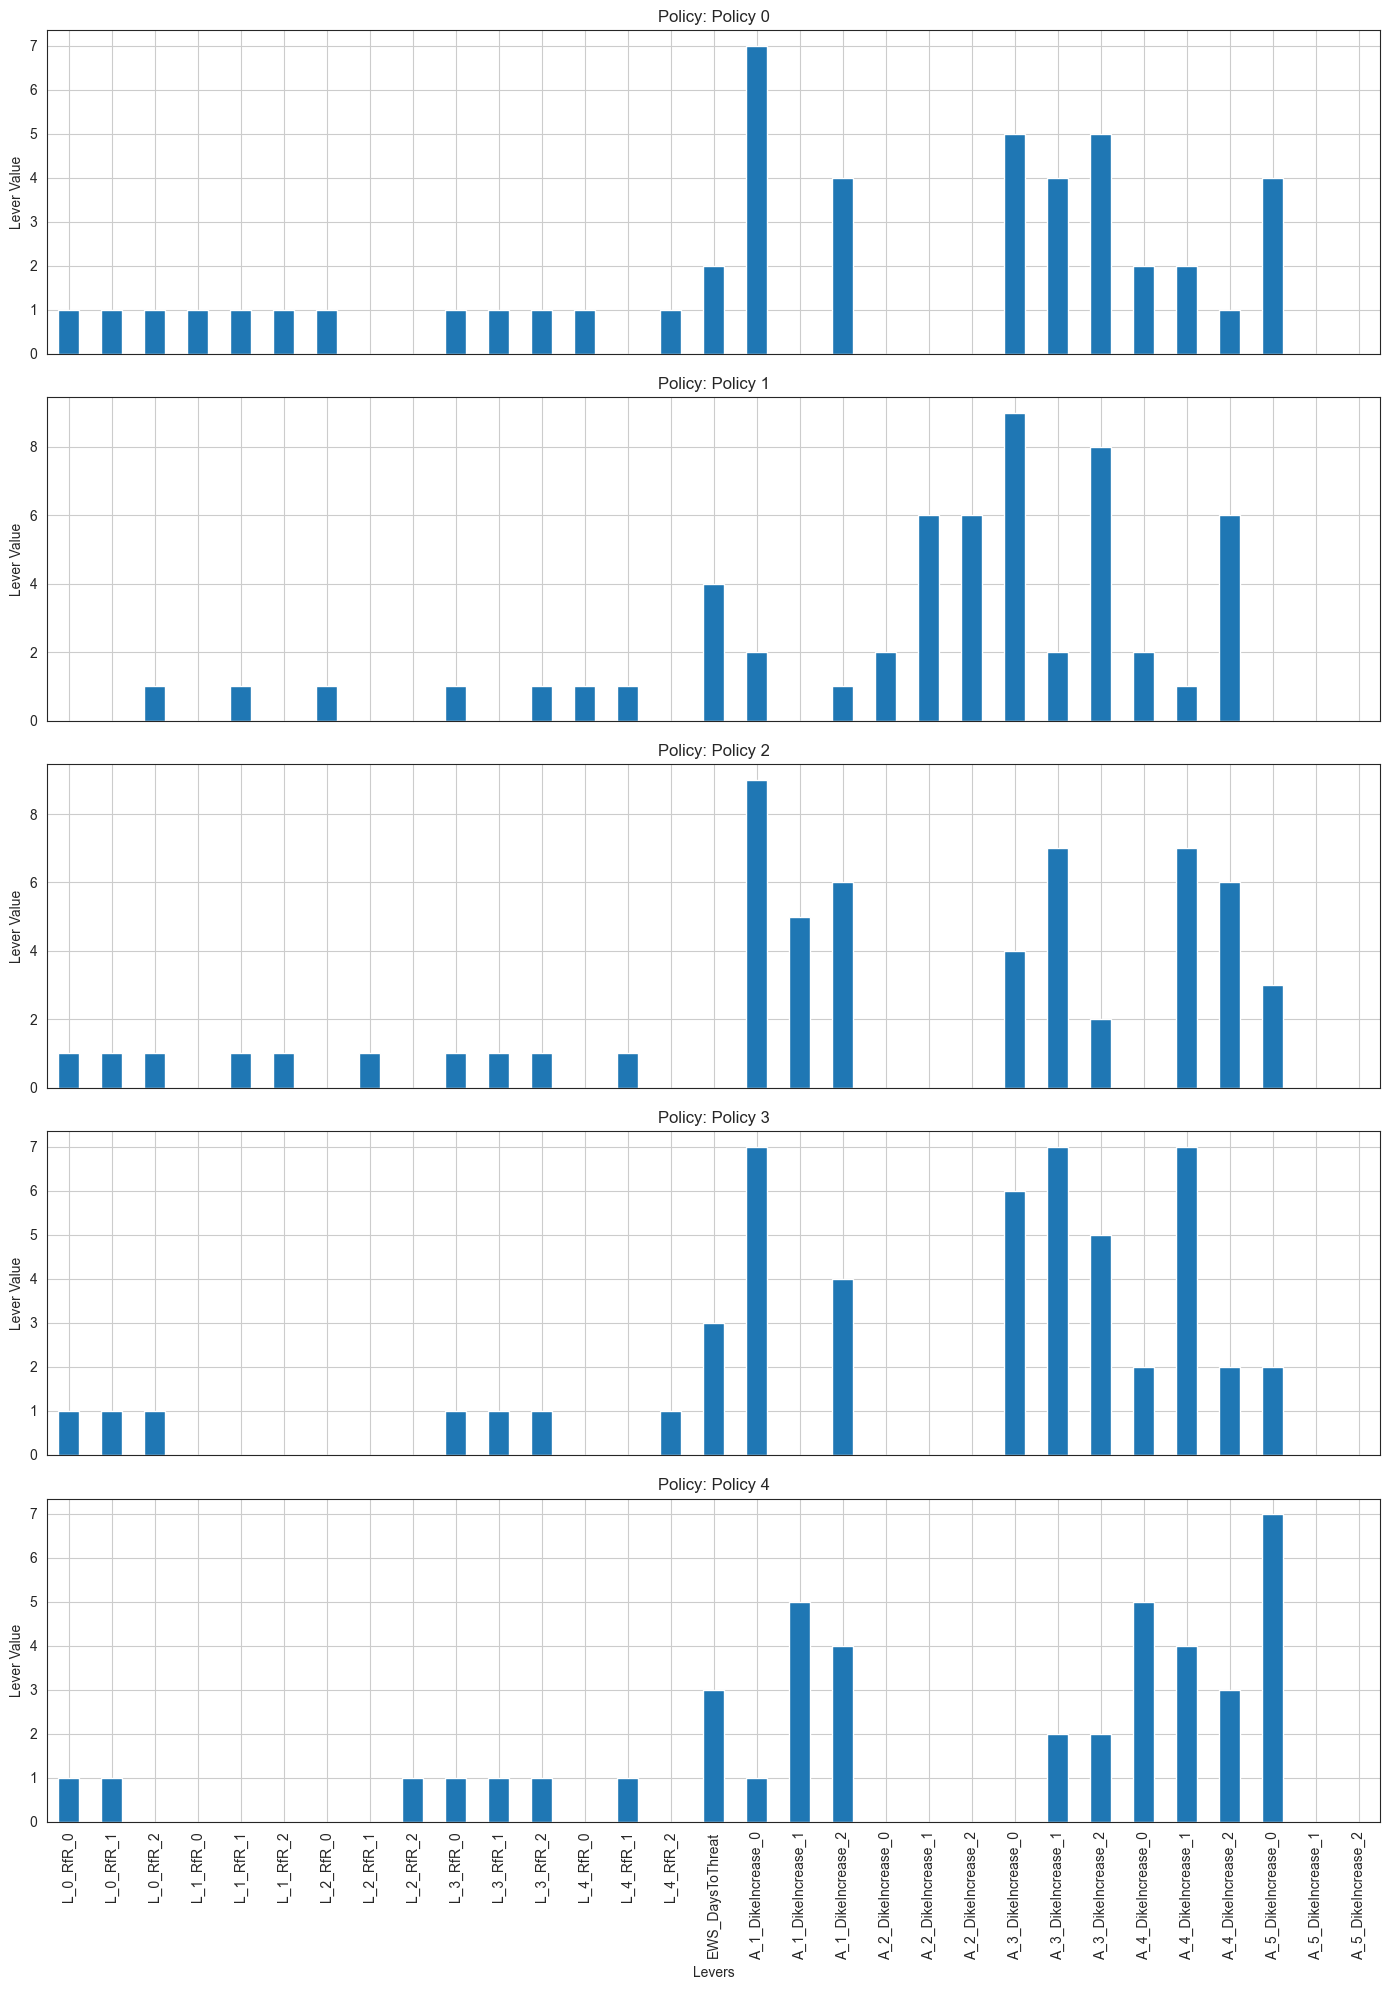

In [44]:

import pandas as pd
import matplotlib.pyplot as plt

# Load the optimized policies
optimized_df = pd.read_excel("./optimized_policies.xlsx")

# Extract all lever columns (assuming first column is 'Policy')
lever_columns = optimized_df.columns.drop("Policy")

# Set up the plot
n_policies = len(optimized_df)
fig, axes = plt.subplots(n_policies, 1, figsize=(14, 4 * n_policies), sharex=True)

# Ensure axes is always iterable
if n_policies == 1:
    axes = [axes]

# Plot each policy's levers
for i, row in optimized_df.iterrows():
    ax = axes[i]
    row[lever_columns].plot(kind="bar", ax=ax)
    ax.set_title(f"Policy: {row['Policy']}", fontsize=12)
    ax.set_ylabel("Lever Value")
    ax.grid(True)

plt.xlabel("Levers")
plt.tight_layout()
plt.show()
